In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_X_path = '/content/drive/Shareddrives/AAX_Alejandro_Joan_Pau/Seminari 3/rssi_data.csv'
dataset_Y_path = '/content/drive/Shareddrives/AAX_Alejandro_Joan_Pau/Seminari 3/labels_data.csv'

In [ ]:
import pandas as pd

X_column_names = ['rssi_AP1', 'rssi_AP2', 'rssi_AP3']
Y_column_names = ['position']

X_df = pd.read_csv(dataset_X_path, names=X_column_names)
Y_df = pd.read_csv(dataset_Y_path, names=Y_column_names)

data = pd.concat([X_df, Y_df], axis=1)

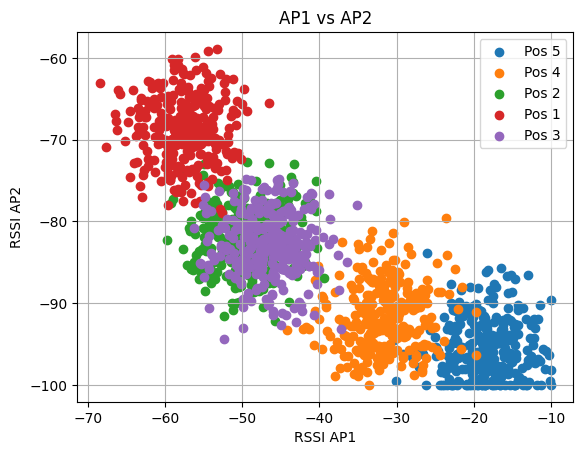

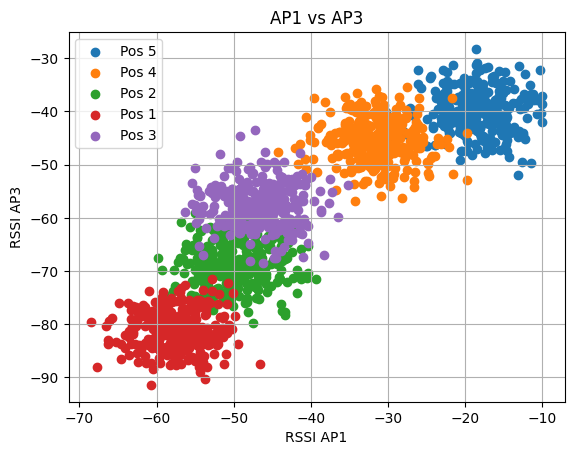

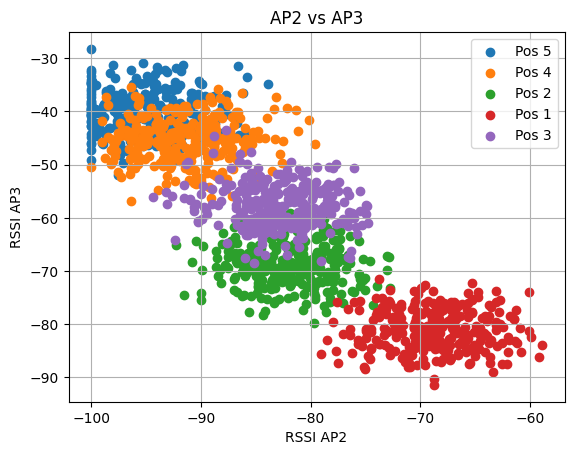

In [ ]:
import matplotlib.pyplot as plt

# AP1 vs AP2 (2D)
plt.figure()

for pos in data['position'].unique():
    subset = data[data['position'] == pos]
    plt.scatter(subset['rssi_AP1'], subset['rssi_AP2'], label=f'Pos {pos}')

plt.xlabel('RSSI AP1')
plt.ylabel('RSSI AP2')
plt.title('AP1 vs AP2')
plt.legend()
plt.grid()
plt.show()

# AP1 vs AP3 (2D)
plt.figure()

for pos in data['position'].unique():
    subset = data[data['position'] == pos]
    plt.scatter(subset['rssi_AP1'], subset['rssi_AP3'], label=f'Pos {pos}')

plt.xlabel('RSSI AP1')
plt.ylabel('RSSI AP3')
plt.title('AP1 vs AP3')
plt.legend()
plt.grid()
plt.show()

# AP2 vs AP3 (2D)
plt.figure()

for pos in data['position'].unique():
    subset = data[data['position'] == pos]
    plt.scatter(subset['rssi_AP2'], subset['rssi_AP3'], label=f'Pos {pos}')

plt.xlabel('RSSI AP2')
plt.ylabel('RSSI AP3')
plt.title('AP2 vs AP3')
plt.legend()
plt.grid()
plt.show()

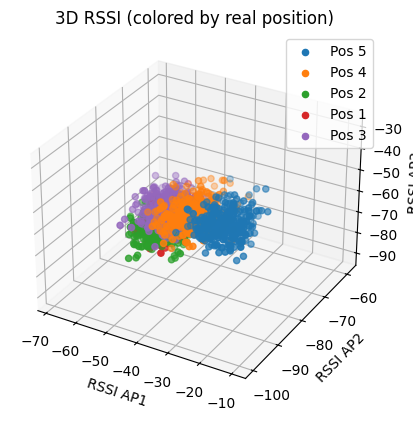

In [ ]:
# 3-D plot showing the RSSI perceived by each of the APs

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for pos in data['position'].unique():
    subset = data[data['position'] == pos]
    ax.scatter(
        subset['rssi_AP1'],
        subset['rssi_AP2'],
        subset['rssi_AP3'],
        label=f'Pos {pos}'
    )

ax.set_xlabel('RSSI AP1')
ax.set_ylabel('RSSI AP2')
ax.set_zlabel('RSSI AP3')
ax.legend()
plt.title('3D RSSI (colored by real position)')
plt.show()

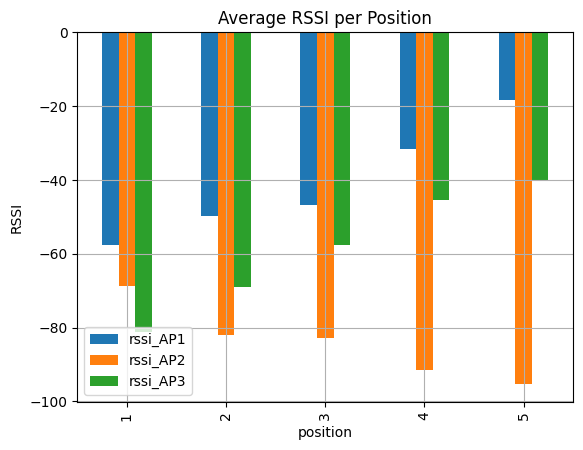

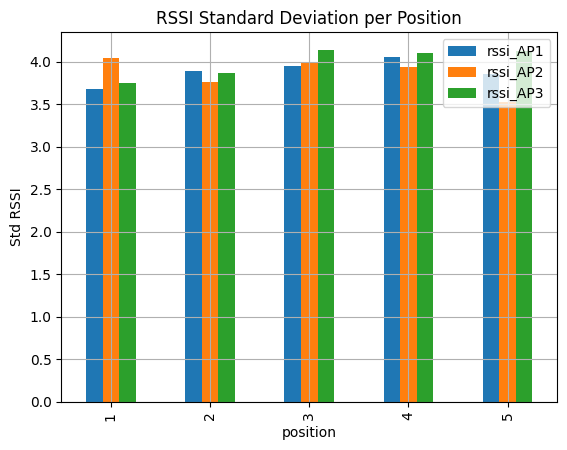

In [ ]:
import pandas as pd

# Statistics behind each of the considered points

stats = data.groupby('position').agg(['mean', 'std'])

# Plot of the average RSSI per position
mean_values = data.groupby('position').mean()

mean_values.plot(kind='bar')
plt.title('Average RSSI per Position')
plt.ylabel('RSSI')
plt.grid()
plt.show()

# Plot of the RSSI Standard Deviation per Position
std_values = data.groupby('position').std()

std_values.plot(kind='bar')
plt.title('RSSI Standard Deviation per Position')
plt.ylabel('Std RSSI')
plt.grid()
plt.show()

In [ ]:
import random
import numpy as np

k = 5 # Number of positions P = 5
T = 100 # Maximum iterations

# Random centroids initialization
centroids = np.array([
    [random.uniform(-100, 0), random.uniform(-100, 0), random.uniform(-100, 0)]
    for i in range(k)
])

assignments = None

for t in range(T):
    new_assignments = []

    # Step 1: assign each point to the closest centroid
    for point in X_df.values:
        distances = [np.linalg.norm(point - centroid) for centroid in centroids]
        closest_centroid_index = np.argmin(distances)
        new_assignments.append(closest_centroid_index)

    new_assignments = np.array(new_assignments)

    # Step 2: check convergence
    if assignments is not None and np.array_equal(assignments, new_assignments):
        print(f"Converged at iteration {t}")
        break

    assignments = new_assignments

    # Step 3: recalculate centroids positions
    new_centroids = []
    for i in range(k):
        points_in_cluster = X_df.values[assignments == i] # We take the points assigned to that centroid

        if len(points_in_cluster) > 0:
            new_centroid = np.mean(points_in_cluster, axis=0)
        else:
            # If a cluster becomes empty, we initialize it randomly again
            new_centroid = np.array([
                random.uniform(-100, 0),
                random.uniform(-100, 0),
                random.uniform(-100, 0)
            ])

        new_centroids.append(new_centroid)

    centroids = np.array(new_centroids)

else:
    print(f"Iteration {T} reached without convergence")

Converged at iteration 19


In [ ]:
# Results of the K-Means
results = pd.DataFrame({
    'cluster': assignments,
    'real_position': Y_df['position']
})

# Mapping clusters to positions
mapping = results.groupby('cluster')['real_position'].agg(lambda x: x.value_counts().idxmax())

# Final predictions
predicted_positions = np.array([mapping[c] for c in assignments])

# Accuracy
accuracy = np.mean(predicted_positions == Y_df['position'])
print(f'Accuracy: {accuracy}')

Accuracy: 0.9586666666666667


The accuracy might change depending on the execution. As we initialize the centroids randomly at the beginning and also when they have no points assigned at some iteration, executing the code multiple times might lead us to see accuracies varying, usually between 0.77 and 0.96

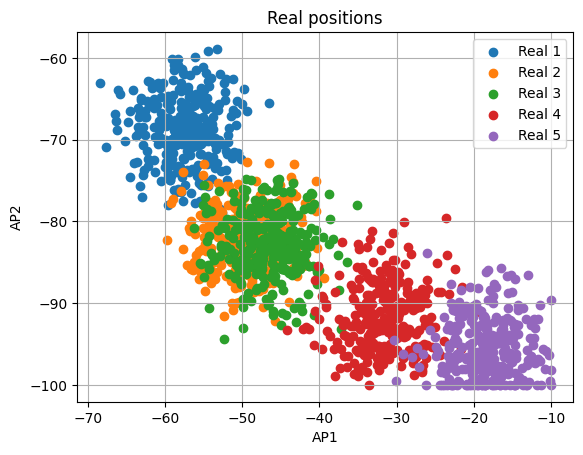

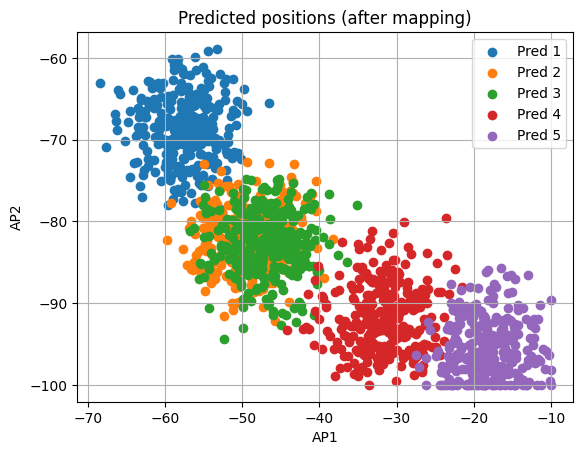

In [ ]:
# Real plot
plt.figure()
for pos in np.unique(Y_df['position']):
    subset = X_df[Y_df['position'] == pos]
    plt.scatter(subset['rssi_AP1'], subset['rssi_AP2'], label=f'Real {pos}')

plt.legend()
plt.title('Real positions')
plt.xlabel('AP1')
plt.ylabel('AP2')
plt.grid()
plt.show()

# Comparative plot
plt.figure()
for pos in np.unique(predicted_positions):
    subset = X_df[predicted_positions == pos]
    plt.scatter(subset['rssi_AP1'], subset['rssi_AP2'], label=f'Pred {pos}')

plt.legend()
plt.title('Predicted positions (after mapping)')
plt.xlabel('AP1')
plt.ylabel('AP2')
plt.grid()
plt.show()

When the accuracy is high, we will see almost identical plots up here, but if the accuracy decreases, we might see a cluster less in the second plot. That is because we can't guarantee that a cluster that stopped having points will get a point ever again.